In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import cifar10

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 7 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)


# Model
def build_cnn(input_shape, num_classes, onehot=False):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    loss = "categorical_crossentropy" if onehot else "sparse_categorical_crossentropy"
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=["accuracy"]
    )
    return model


# Common augmentation layers (create once)
rot = tf.keras.layers.RandomRotation(0.08)
trans = tf.keras.layers.RandomTranslation(0.08, 0.08)
zm = tf.keras.layers.RandomZoom(0.10)
con = tf.keras.layers.RandomContrast(0.10)


# 8 methods (0~7)
def method0(x, y):
    return x, y

def method1(x, y):
    x = rot(x, training=True)
    return x, y

def method2(x, y):
    x = trans(x, training=True)
    return x, y

def method3(x, y):
    x = zm(x, training=True)
    return x, y

def method4(x, y, is_rgb):
    x = rot(x, training=True)
    x = trans(x, training=True)
    x = zm(x, training=True)
    if is_rgb:
        x = con(x, training=True)
    return x, y

# Method 5: MixUp (one-hot y)
def method5(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    alpha = 0.2

    a = tf.random.gamma([batch_size], alpha)
    b = tf.random.gamma([batch_size], alpha)
    lam = a / (a + b + 1e-8)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x = x * lam_x + x2 * (1.0 - lam_x)
    y = y * lam_y + y2 * (1.0 - lam_y)
    return x, y

# Method 6: CutMix (one-hot y, simple batch-wise)
def method6(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    height = tf.shape(x)[1]
    width = tf.shape(x)[2]
    channels = tf.shape(x)[3]

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    alpha = 1.0
    a = tf.random.gamma([], alpha)
    b = tf.random.gamma([], alpha)
    lam = a / (a + b + 1e-8)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(width, tf.float32) * cut_ratio, tf.int32)
    cut_h = tf.cast(tf.cast(height, tf.float32) * cut_ratio, tf.int32)

    cx = tf.random.uniform([], 0, width, dtype=tf.int32)
    cy = tf.random.uniform([], 0, height, dtype=tf.int32)

    x1 = tf.clip_by_value(cx - cut_w // 2, 0, width)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, width)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, height)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, height)

    xs = tf.range(width)[None, :]
    ys = tf.range(height)[:, None]
    inside = tf.logical_and(
        tf.logical_and(xs >= x1, xs < x2b),
        tf.logical_and(ys >= y1, ys < y2b)
    )

    mask = tf.cast(inside, tf.float32)[None, ..., None]
    mask = tf.broadcast_to(mask, [batch_size, height, width, channels])

    x = x * (1.0 - mask) + x2 * mask

    area = tf.cast((x2b - x1) * (y2b - y1), tf.float32)
    lam_real = 1.0 - area / (tf.cast(height * width, tf.float32) + 1e-8)
    y = y * lam_real + y2 * (1.0 - lam_real)

    return x, y

# Method 7: RandAugment (built-in)
randaugment = tf.keras.layers.RandAugment(
    value_range=(0.0, 1.0),
    num_ops=2,
    factor=0.5
)

def method7(x, y, is_rgb):
    if not is_rgb:
        # 1-channel -> 3-channel
        x = tf.concat([x, x, x], axis=-1)

        # RandAugment needs 3 channels
        x = randaugment(x, training=True)

        # 3-channel -> 1-channel
        x = tf.reduce_mean(x, axis=-1, keepdims=True)
    else:
        x = randaugment(x, training=True)

    return x, y





# Train each method
def run_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    use_onehot = (method_id == 5 or method_id == 6)
    model = build_cnn(input_shape, num_classes, onehot=use_onehot)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    methods = [method0, method1, method2, method3, method4, method5, method6, method7]

    def train_map(x, y):
        for i in range(len(methods)):
            if i == method_id:
                if i == 4:
                    return methods[i](x, y, is_rgb)
                elif i in [5, 6]:
                    return methods[i](x, y, num_classes)
                elif i == 7:
                    return methods[i](x, y, is_rgb) 
                else:
                    return methods[i](x, y)


    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    if use_onehot:
        def val_map(x, y):
            y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y
        val_ds = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE)

    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc



# Plot
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

##  CIFAR-10



CIFAR-10 - Method 0
--------------------
Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.4729 - loss: 1.4733 - val_accuracy: 0.5549 - val_loss: 1.2828
Epoch 2/20
750/750 - 4s - 6ms/step - accuracy: 0.5961 - loss: 1.1473 - val_accuracy: 0.6077 - val_loss: 1.1371
Epoch 3/20
750/750 - 4s - 6ms/step - accuracy: 0.6510 - loss: 1.0034 - val_accuracy: 0.6519 - val_loss: 1.0008
Epoch 4/20
750/750 - 4s - 6ms/step - accuracy: 0.6820 - loss: 0.9135 - val_accuracy: 0.6580 - val_loss: 0.9907
Epoch 5/20
750/750 - 4s - 6ms/step - accuracy: 0.7063 - loss: 0.8467 - val_accuracy: 0.6668 - val_loss: 0.9441
Epoch 6/20
750/750 - 4s - 6ms/step - accuracy: 0.7289 - loss: 0.7785 - val_accuracy: 0.6831 - val_loss: 0.9179
Epoch 7/20
750/750 - 4s - 6ms/step - accuracy: 0.7504 - loss: 0.7203 - val_accuracy: 0.6966 - val_loss: 0.8815
Epoch 8/20
750/750 - 4s - 6ms/step - accuracy: 0.7688 - loss: 0.6650 - val_accuracy: 0.6923 - val_loss: 0.9153
Epoch 9/20
750/750 - 5s - 6ms/step - accuracy: 0.7829 - loss: 0.6204 

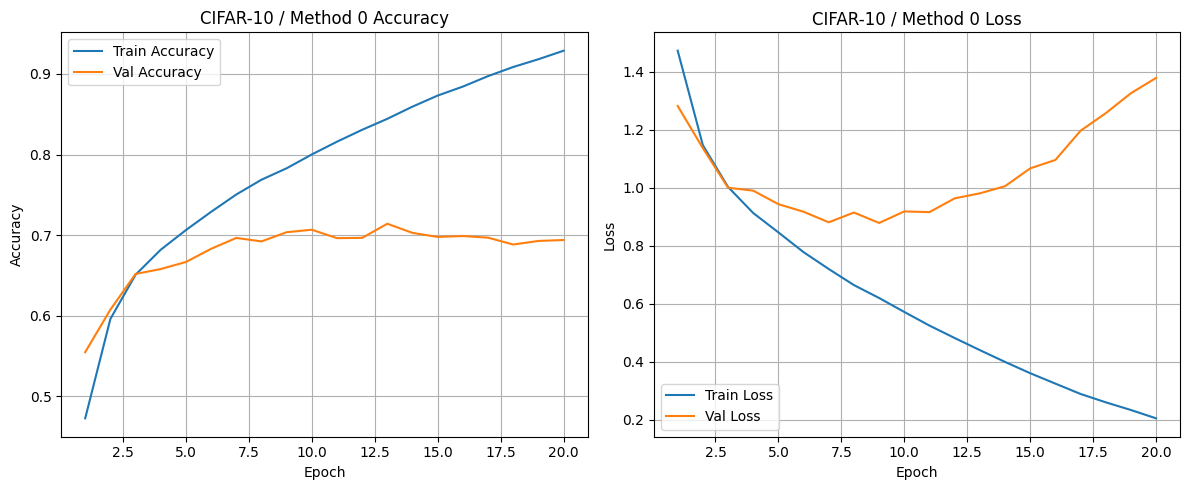



CIFAR-10 - Method 1
--------------------
Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.4096 - loss: 1.6296 - val_accuracy: 0.5182 - val_loss: 1.3517
Epoch 2/20
750/750 - 5s - 6ms/step - accuracy: 0.5316 - loss: 1.3145 - val_accuracy: 0.5600 - val_loss: 1.2332
Epoch 3/20
750/750 - 5s - 6ms/step - accuracy: 0.5817 - loss: 1.1846 - val_accuracy: 0.6050 - val_loss: 1.1064
Epoch 4/20
750/750 - 5s - 6ms/step - accuracy: 0.6106 - loss: 1.1063 - val_accuracy: 0.6335 - val_loss: 1.0382
Epoch 5/20
750/750 - 5s - 7ms/step - accuracy: 0.6295 - loss: 1.0492 - val_accuracy: 0.6269 - val_loss: 1.0720
Epoch 6/20
750/750 - 5s - 6ms/step - accuracy: 0.6490 - loss: 1.0063 - val_accuracy: 0.6345 - val_loss: 1.0748
Epoch 7/20
750/750 - 5s - 6ms/step - accuracy: 0.6585 - loss: 0.9749 - val_accuracy: 0.6593 - val_loss: 0.9751
Epoch 8/20
750/750 - 5s - 6ms/step - accuracy: 0.6709 - loss: 0.9409 - val_accuracy: 0.6815 - val_loss: 0.9106
Epoch 9/20
750/750 - 5s - 6ms/step - accuracy: 0.6791 - loss: 0.9125 

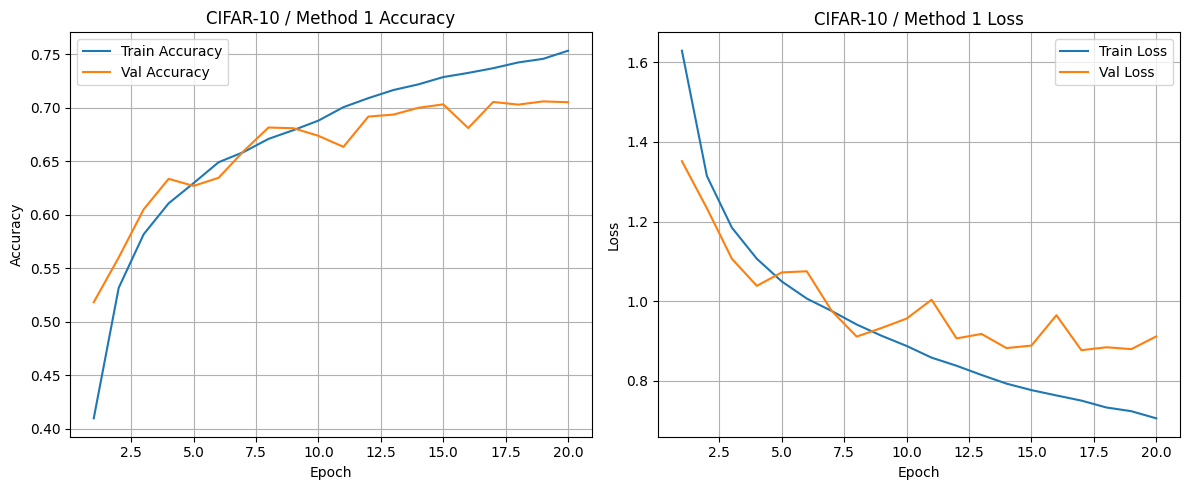



CIFAR-10 - Method 2
--------------------
Epoch 1/20
750/750 - 6s - 7ms/step - accuracy: 0.4439 - loss: 1.5440 - val_accuracy: 0.5635 - val_loss: 1.2277
Epoch 2/20
750/750 - 5s - 6ms/step - accuracy: 0.5656 - loss: 1.2277 - val_accuracy: 0.6009 - val_loss: 1.1274
Epoch 3/20
750/750 - 5s - 6ms/step - accuracy: 0.6152 - loss: 1.0985 - val_accuracy: 0.6446 - val_loss: 0.9995
Epoch 4/20
750/750 - 5s - 6ms/step - accuracy: 0.6443 - loss: 1.0182 - val_accuracy: 0.6675 - val_loss: 0.9532
Epoch 5/20
750/750 - 5s - 6ms/step - accuracy: 0.6617 - loss: 0.9662 - val_accuracy: 0.6618 - val_loss: 0.9652
Epoch 6/20
750/750 - 5s - 6ms/step - accuracy: 0.6815 - loss: 0.9141 - val_accuracy: 0.6743 - val_loss: 0.9468
Epoch 7/20
750/750 - 5s - 6ms/step - accuracy: 0.6939 - loss: 0.8818 - val_accuracy: 0.7018 - val_loss: 0.8508
Epoch 8/20
750/750 - 5s - 6ms/step - accuracy: 0.7066 - loss: 0.8428 - val_accuracy: 0.7107 - val_loss: 0.8282
Epoch 9/20
750/750 - 5s - 6ms/step - accuracy: 0.7153 - loss: 0.8136 

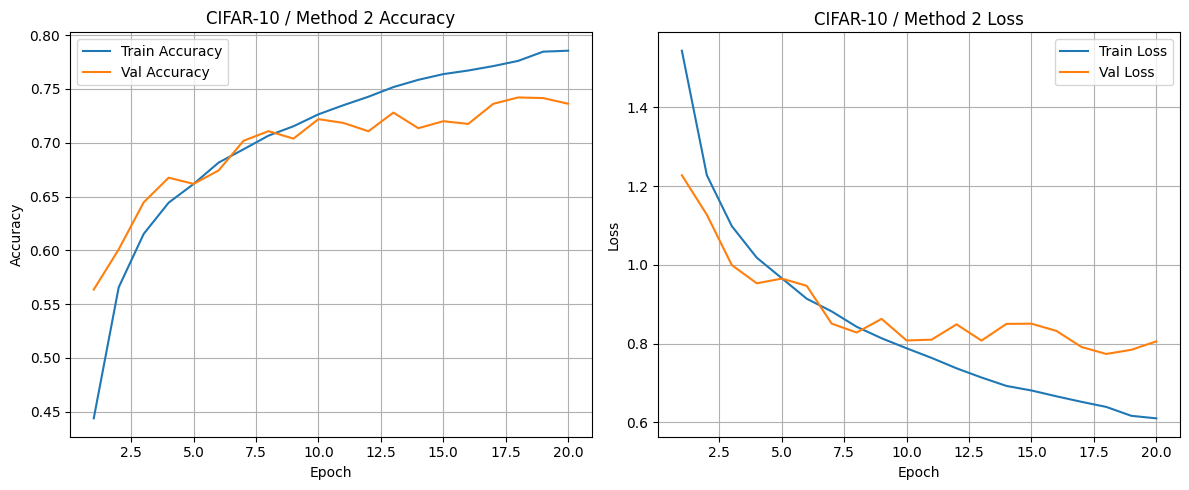



CIFAR-10 - Method 3
--------------------
Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.4611 - loss: 1.4934 - val_accuracy: 0.5683 - val_loss: 1.2146
Epoch 2/20
750/750 - 5s - 6ms/step - accuracy: 0.5900 - loss: 1.1668 - val_accuracy: 0.5908 - val_loss: 1.1772
Epoch 3/20
750/750 - 5s - 6ms/step - accuracy: 0.6409 - loss: 1.0291 - val_accuracy: 0.6430 - val_loss: 1.0121
Epoch 4/20
750/750 - 5s - 6ms/step - accuracy: 0.6716 - loss: 0.9411 - val_accuracy: 0.6503 - val_loss: 1.0139
Epoch 5/20
750/750 - 5s - 6ms/step - accuracy: 0.6938 - loss: 0.8768 - val_accuracy: 0.6608 - val_loss: 0.9726
Epoch 6/20
750/750 - 5s - 6ms/step - accuracy: 0.7169 - loss: 0.8120 - val_accuracy: 0.6827 - val_loss: 0.9196
Epoch 7/20
750/750 - 5s - 6ms/step - accuracy: 0.7343 - loss: 0.7613 - val_accuracy: 0.6886 - val_loss: 0.9321
Epoch 8/20
750/750 - 5s - 7ms/step - accuracy: 0.7531 - loss: 0.7061 - val_accuracy: 0.7039 - val_loss: 0.8850
Epoch 9/20
750/750 - 5s - 7ms/step - accuracy: 0.7682 - loss: 0.6643 

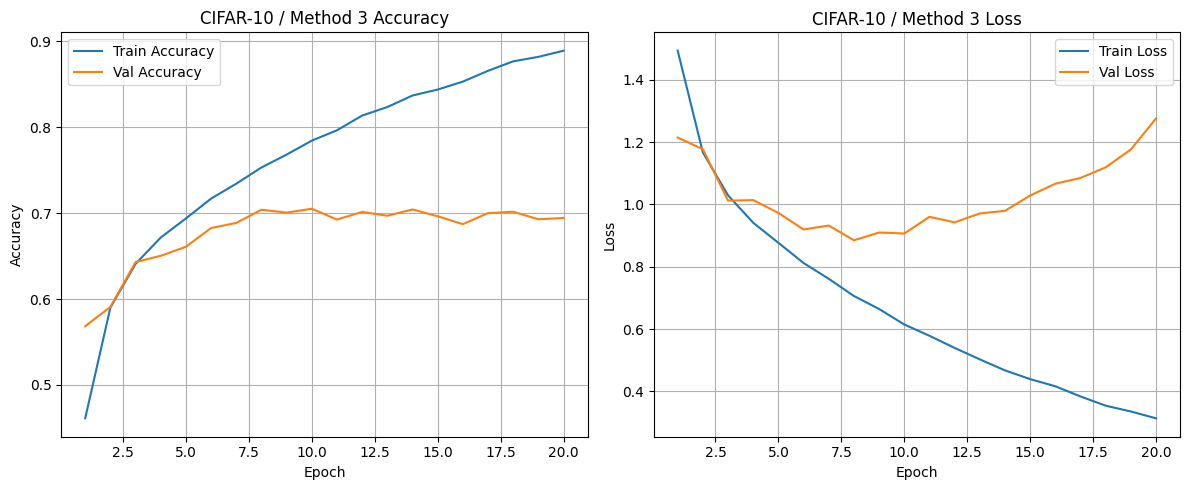



CIFAR-10 - Method 4
--------------------
Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.3969 - loss: 1.6621 - val_accuracy: 0.4864 - val_loss: 1.4305
Epoch 2/20
750/750 - 5s - 7ms/step - accuracy: 0.4965 - loss: 1.4060 - val_accuracy: 0.5261 - val_loss: 1.3133
Epoch 3/20
750/750 - 5s - 7ms/step - accuracy: 0.5417 - loss: 1.2874 - val_accuracy: 0.5491 - val_loss: 1.2570
Epoch 4/20
750/750 - 5s - 7ms/step - accuracy: 0.5686 - loss: 1.2157 - val_accuracy: 0.5947 - val_loss: 1.1579
Epoch 5/20
750/750 - 5s - 7ms/step - accuracy: 0.5896 - loss: 1.1637 - val_accuracy: 0.5977 - val_loss: 1.1403
Epoch 6/20
750/750 - 5s - 7ms/step - accuracy: 0.6005 - loss: 1.1262 - val_accuracy: 0.5865 - val_loss: 1.2015
Epoch 7/20
750/750 - 5s - 7ms/step - accuracy: 0.6118 - loss: 1.0986 - val_accuracy: 0.6277 - val_loss: 1.0368
Epoch 8/20
750/750 - 5s - 7ms/step - accuracy: 0.6252 - loss: 1.0690 - val_accuracy: 0.6533 - val_loss: 0.9847
Epoch 9/20
750/750 - 5s - 7ms/step - accuracy: 0.6308 - loss: 1.0479 

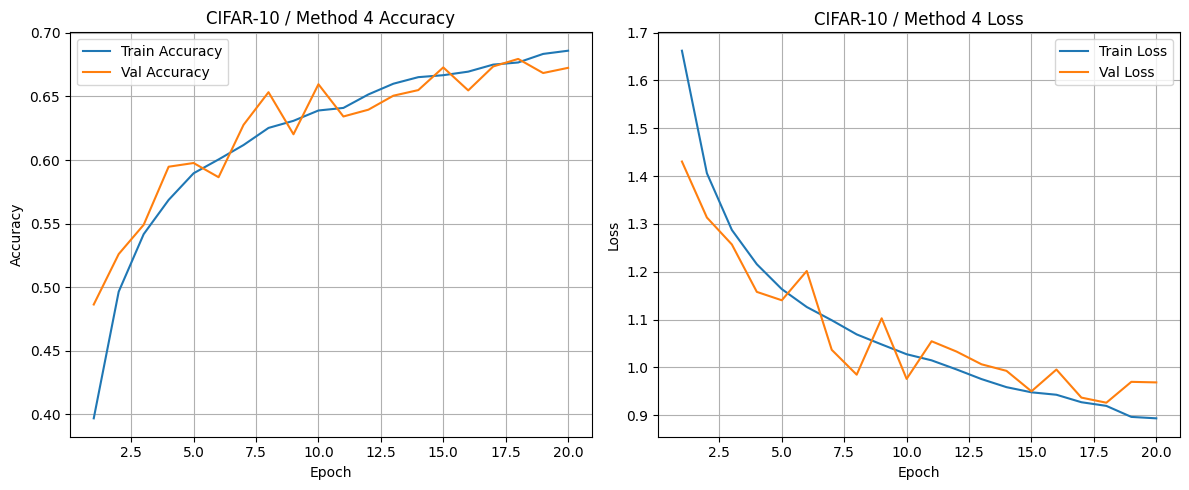



CIFAR-10 - Method 5
--------------------
Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.4200 - loss: 1.6890 - val_accuracy: 0.5409 - val_loss: 1.3035
Epoch 2/20
750/750 - 5s - 6ms/step - accuracy: 0.5527 - loss: 1.4089 - val_accuracy: 0.5698 - val_loss: 1.2260
Epoch 3/20
750/750 - 5s - 6ms/step - accuracy: 0.6041 - loss: 1.2970 - val_accuracy: 0.6277 - val_loss: 1.0808
Epoch 4/20
750/750 - 5s - 6ms/step - accuracy: 0.6344 - loss: 1.2200 - val_accuracy: 0.6454 - val_loss: 1.0259
Epoch 5/20
750/750 - 5s - 6ms/step - accuracy: 0.6571 - loss: 1.1745 - val_accuracy: 0.6668 - val_loss: 0.9844
Epoch 6/20
750/750 - 5s - 6ms/step - accuracy: 0.6810 - loss: 1.1244 - val_accuracy: 0.6807 - val_loss: 0.9376
Epoch 7/20
750/750 - 5s - 6ms/step - accuracy: 0.6969 - loss: 1.0822 - val_accuracy: 0.6892 - val_loss: 0.9008
Epoch 8/20
750/750 - 5s - 6ms/step - accuracy: 0.7146 - loss: 1.0448 - val_accuracy: 0.6913 - val_loss: 0.9085
Epoch 9/20
750/750 - 5s - 6ms/step - accuracy: 0.7323 - loss: 1.0070 

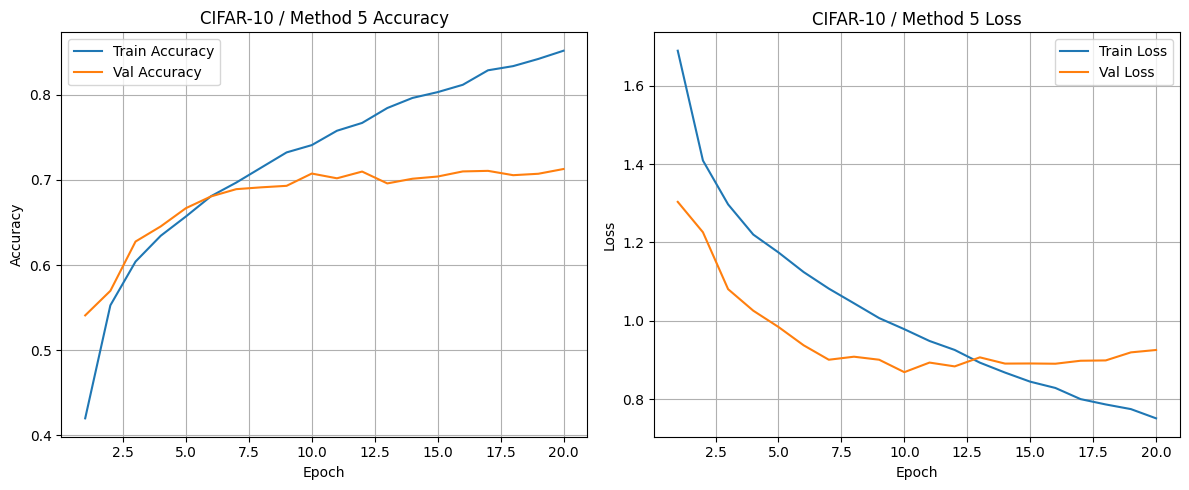



CIFAR-10 - Method 6
--------------------
Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.3226 - loss: 1.9591 - val_accuracy: 0.5149 - val_loss: 1.4039
Epoch 2/20
750/750 - 5s - 6ms/step - accuracy: 0.4286 - loss: 1.7740 - val_accuracy: 0.5615 - val_loss: 1.2804
Epoch 3/20
750/750 - 5s - 6ms/step - accuracy: 0.4661 - loss: 1.7068 - val_accuracy: 0.6003 - val_loss: 1.1815
Epoch 4/20
750/750 - 5s - 6ms/step - accuracy: 0.4916 - loss: 1.6627 - val_accuracy: 0.6307 - val_loss: 1.1159
Epoch 5/20
750/750 - 5s - 6ms/step - accuracy: 0.5041 - loss: 1.6355 - val_accuracy: 0.6486 - val_loss: 1.0603
Epoch 6/20
750/750 - 5s - 6ms/step - accuracy: 0.5200 - loss: 1.6065 - val_accuracy: 0.6381 - val_loss: 1.0886
Epoch 7/20
750/750 - 4s - 6ms/step - accuracy: 0.5292 - loss: 1.5878 - val_accuracy: 0.6659 - val_loss: 1.0197
Epoch 8/20
750/750 - 5s - 6ms/step - accuracy: 0.5419 - loss: 1.5677 - val_accuracy: 0.6610 - val_loss: 1.0171
Epoch 9/20
750/750 - 5s - 6ms/step - accuracy: 0.5490 - loss: 1.5545 

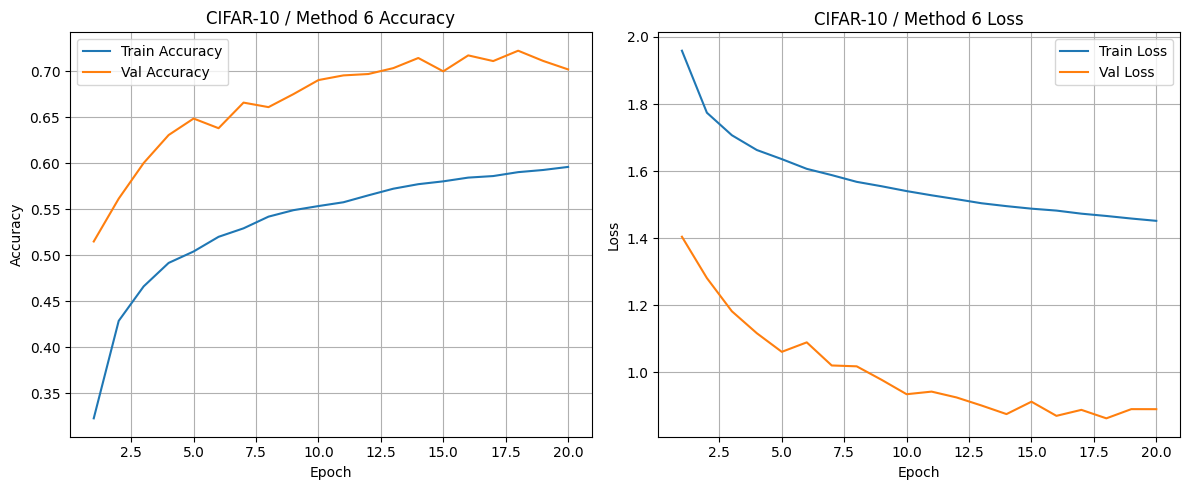



CIFAR-10 - Method 7
--------------------
Epoch 1/20
750/750 - 9s - 12ms/step - accuracy: 0.2939 - loss: 1.9558 - val_accuracy: 0.4880 - val_loss: 1.4552
Epoch 2/20
750/750 - 9s - 12ms/step - accuracy: 0.3794 - loss: 1.7569 - val_accuracy: 0.5518 - val_loss: 1.3242
Epoch 3/20
750/750 - 8s - 11ms/step - accuracy: 0.4254 - loss: 1.6404 - val_accuracy: 0.5838 - val_loss: 1.2155
Epoch 4/20
750/750 - 8s - 11ms/step - accuracy: 0.4459 - loss: 1.5838 - val_accuracy: 0.5938 - val_loss: 1.1918
Epoch 5/20
750/750 - 8s - 11ms/step - accuracy: 0.4628 - loss: 1.5339 - val_accuracy: 0.6257 - val_loss: 1.1108
Epoch 6/20
750/750 - 8s - 11ms/step - accuracy: 0.4803 - loss: 1.4890 - val_accuracy: 0.6376 - val_loss: 1.0499
Epoch 7/20
750/750 - 8s - 11ms/step - accuracy: 0.4992 - loss: 1.4326 - val_accuracy: 0.6275 - val_loss: 1.0618
Epoch 8/20
750/750 - 8s - 11ms/step - accuracy: 0.5023 - loss: 1.4294 - val_accuracy: 0.6626 - val_loss: 0.9790
Epoch 9/20
750/750 - 8s - 11ms/step - accuracy: 0.5176 - loss

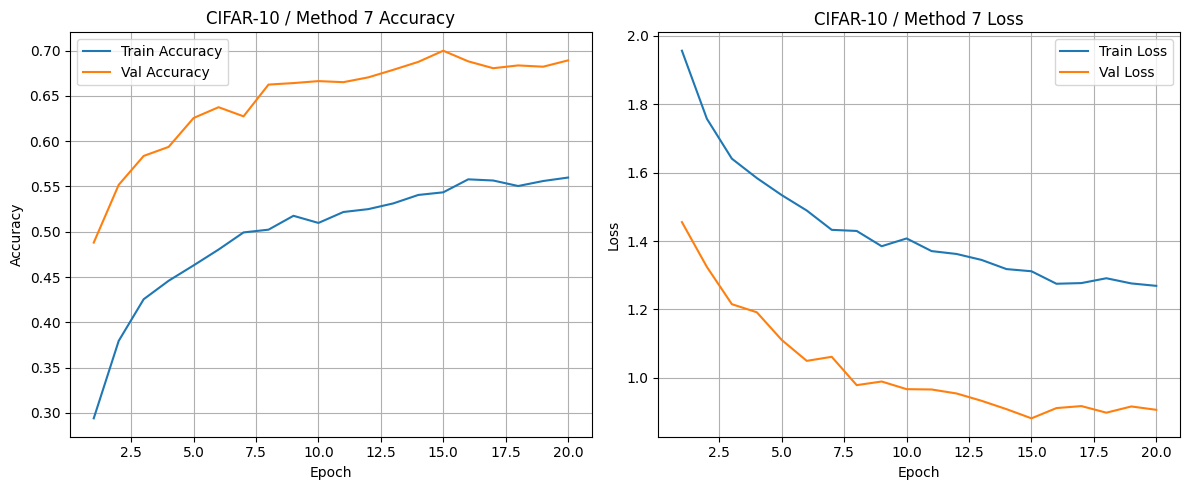


Final accuracy summary (CIFAR-10):
Method 0: train_acc=0.9287, val_acc=0.6940
Method 1: train_acc=0.7533, val_acc=0.7052
Method 2: train_acc=0.7855, val_acc=0.7362
Method 3: train_acc=0.8891, val_acc=0.6943
Method 4: train_acc=0.6860, val_acc=0.6725
Method 5: train_acc=0.8518, val_acc=0.7128
Method 6: train_acc=0.5960, val_acc=0.7020
Method 7: train_acc=0.5599, val_acc=0.6893


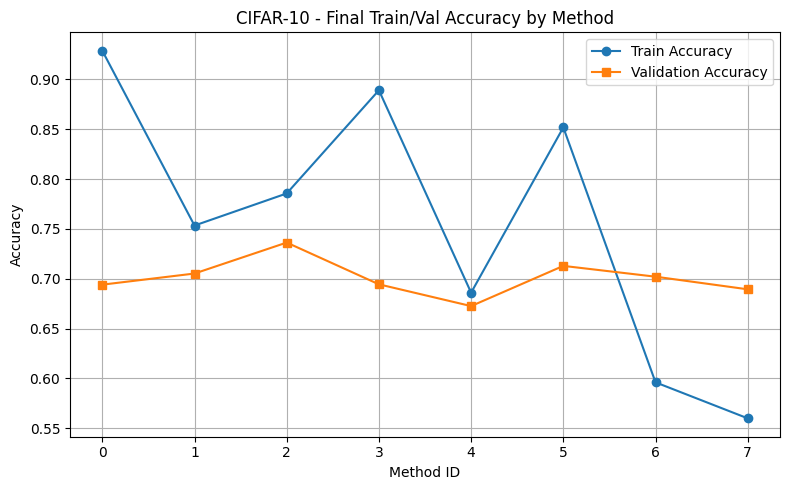

In [3]:
(X0, y0), (X1, y1) = cifar10.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0).reshape(-1)

# float32 + [0,1]
X = X.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (32, 32, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(8):
    print("\n")
    print(f"CIFAR-10 - Method {method_id}")
    print("--------------------")

    history, train_acc, val_acc = run_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape,
        num_classes=num_classes,
        method_id=method_id,
        is_rgb=is_rgb
    )

    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"CIFAR-10 / Method {method_id}")

print("\nFinal accuracy summary (CIFAR-10):")
for k in range(8):
    ta, va = results[k]
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="CIFAR-10 - Final Train/Val Accuracy by Method")